In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import numpy.fft as fft
import sys
sys.path.append('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/')
from util import *
from copy import deepcopy
from tqdm import tqdm

In [2]:
from glob import glob
sub_names = glob("/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/drift_6/sub_baseline_once/G15_drift_6_arcdrift-M*-specs_T-bld.hdf5")
sub = h5py.File(sub_names[16],'r')

rfi_names = glob("/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/drift_6/cor_vel_once/G15_drift_6_arcdrift-M*-*pdrfi*")
rfi =  h5py.File(rfi_names[16],'r')
sub_names[16],rfi_names[16]

('/data/inspur_disk01/userdir/ucas_students/xuc/FAST/G15/newG15/drift_6/sub_baseline_once/G15_drift_6_arcdrift-M17_W-20200605-specs_T-bld.hdf5',
 './data/G15_drift_6_arcdrift-M17_W-20200605-specs_T-bld-pdrfi.hdf5')

In [3]:
freq = sub['freq'][:]
data = get_data(sub,polar='average')
is_rfi = rfi['is_rfi'][:]

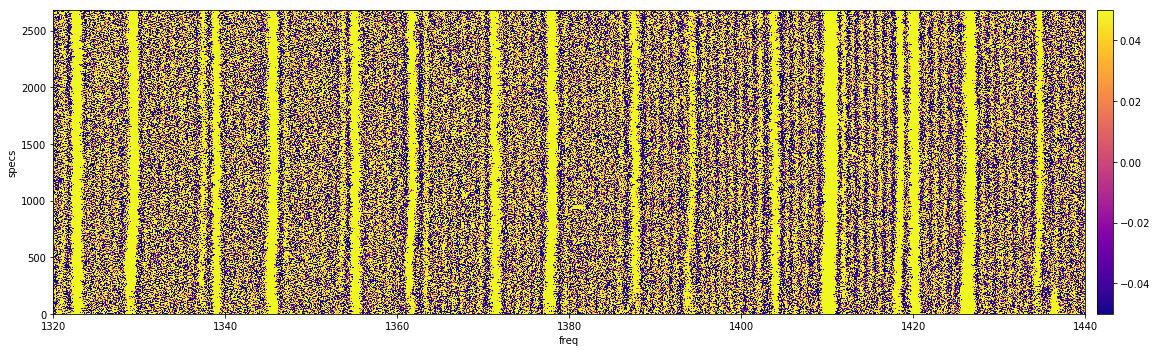

In [4]:
plot_waterfall(sub,data = data,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))

# replace RFI

In [4]:
sg_window = 1
sg_polyorder = 7
times_lower = 5
mw_lower = 1e4

银河系影响sg滤波

In [5]:
# global
mw_use = (freq>=1420.2)&(freq<=1420.55)
fdelta = freq[1]-freq[0]
whole_rfi = np.all(is_rfi,axis = 1)
not_rfi_num = np.arange(data.shape[0])[~whole_rfi]
is_rfi_num = np.arange(data.shape[0])[whole_rfi]     

In [6]:
is_rfi_no_mw = deepcopy(is_rfi)
is_rfi_no_mw[:,mw_use] = False
is_rfi_no_mw[is_rfi_num,:] = True
data_no_mw = deepcopy(data)
data_no_mw[:,mw_use] = 0
data_rmrfi = deepcopy(data)
data_rmrfi[is_rfi_num,:] = np.nan

In [7]:
from util import _round_up_to_odd_integer
window_length = _round_up_to_odd_integer(sg_window/fdelta)
from scipy.signal import savgol_filter
for tn in tqdm(range(data.shape[0])):
    if tn in not_rfi_num:
        sg = savgol_filter(data_no_mw[tn,:],window_length = window_length ,polyorder=sg_polyorder,)
        data_rmrfi[tn,is_rfi_no_mw[tn]] = data[tn,is_rfi_no_mw[tn]] - sg[is_rfi_no_mw[tn]]

100%|██████████| 2683/2683 [00:27<00:00, 96.06it/s] 


(-3, 5)

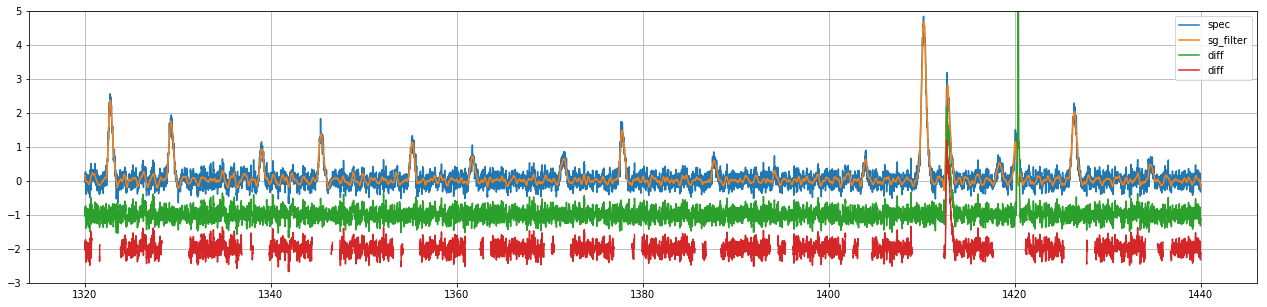

In [8]:
tn = 1420#950
spec = data_no_mw[tn,:]
sg = savgol_filter(spec,window_length = window_length ,polyorder=sg_polyorder,)
spec2 = data_rmrfi[tn,:]
spec_ = deepcopy(spec2)
spec_[is_rfi[tn,:]] = np.nan
fig = plt.figure(figsize=(22,5))
ax = fig.add_subplot(111) 
ax.plot(freq,spec,label = 'spec')
ax.plot(freq,sg,label = 'sg_filter')
ax.plot(freq,spec2-1,label ='diff')
ax.plot(freq,spec_-2,label ='diff')

ax.grid();ax.legend();ax.set_ylim(-3,5)

In [9]:
from markRFI import rms
RMS = rms(data_rmrfi[0,:],freq,[freq[0],freq[0]+20])
thr_lower = RMS*times_lower

low_use = (data_rmrfi > thr_lower) 
from hifast.util import extend_Trues
low_use = extend_Trues(low_use,ext_add =10,leng_lim = 20,axis = -1)
#| np.full(data.shape,mw_use)

In [10]:
data_rmrfi_low_mw = deepcopy(data_rmrfi)
data_rmrfi_low_mw[low_use] = data[low_use]/mw_lower
data_rmrfi_low_mw[is_rfi_num,:] = np.nan

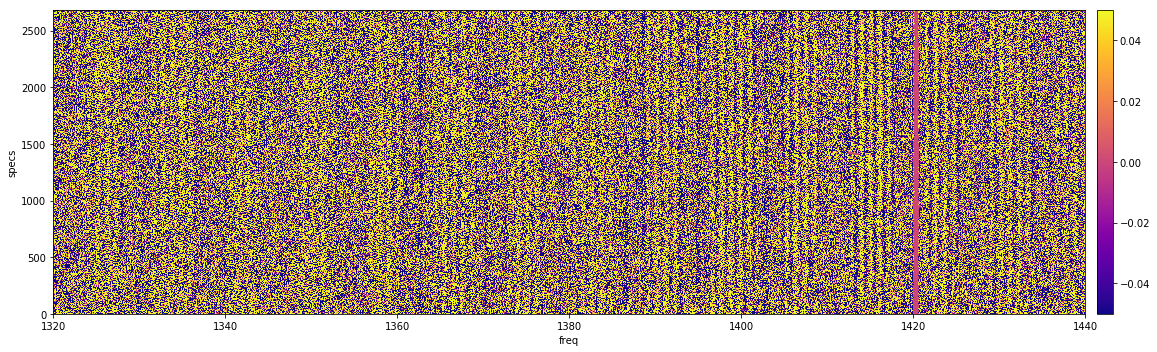

In [11]:
plot_waterfall(sub,data = data_rmrfi_low_mw,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))

(-2, 5)

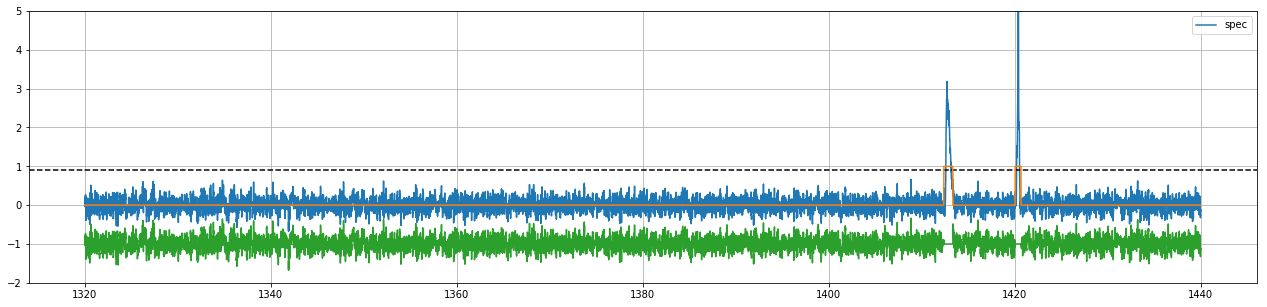

In [12]:
fig = plt.figure(figsize=(22,5))
ax = fig.add_subplot(111) 
ax.plot(freq,spec2,label = 'spec')
ax.axhline(thr_lower,c='k',linestyle = '--')
ax.plot(freq,low_use[tn,:])
ax.plot(freq,data_rmrfi_low_mw[tn,:]-1)
ax.grid();ax.legend();ax.set_ylim(-2,5)

# fit baseline ripple

In [13]:
sw_freq = 0.9254
rfi_freq_step = 1/16.2
amp_thr = 35
sw_n = 5

In [14]:
from fft import FFT
if len(is_rfi_num) > 0:
    data_rmrfi_low_mw = np.delete(data_rmrfi_low_mw,is_rfi_num,axis = 0)
fftf = FFT(data_rmrfi_low_mw, freq)
x = fftf.x
amp_data = fftf.amp

选择哪些模作为驻波？

In [15]:
loc1 = np.argmin(np.abs((x - sw_freq)))
x_loc16 = np.arange(0,x[-1],rfi_freq_step)

N = freq.shape[0]
fs = 1/fdelta
loc16 = np.around(x_loc16 / (fs/N)).astype('int')

loc16_ = np.hstack((loc16 - 1,loc16,loc16 + 1))
loc16_.sort()

(-0.1, 3)

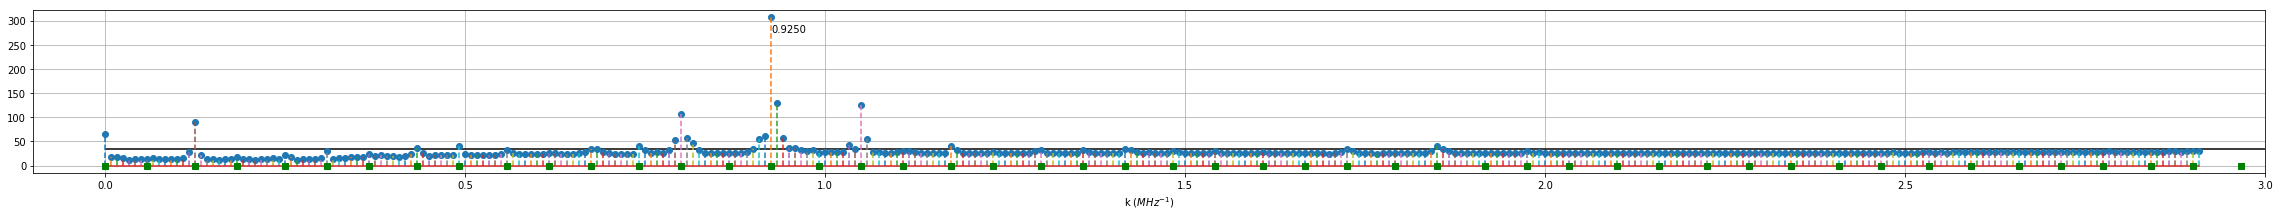

In [16]:
nplot0 = 0
nplot1 = 350
tspec = np.mean(amp_data,axis = 0)
fig,ax = plt.subplots(figsize=(40,3))
ax.stem(x[nplot0:nplot1],tspec[nplot0:nplot1],linefmt='--')
ax.text(x[loc1],tspec[loc1]*.9,f'{x[loc1]:.4f}')
ax.plot(x[loc16],np.zeros_like(loc16),'gs')
ax.hlines(amp_thr,0,3)
ax.grid()
ax.set_xlabel('k ($MHz^{-1}$)')
plt.xlim(-0.1,3)

(-0.1, 3)

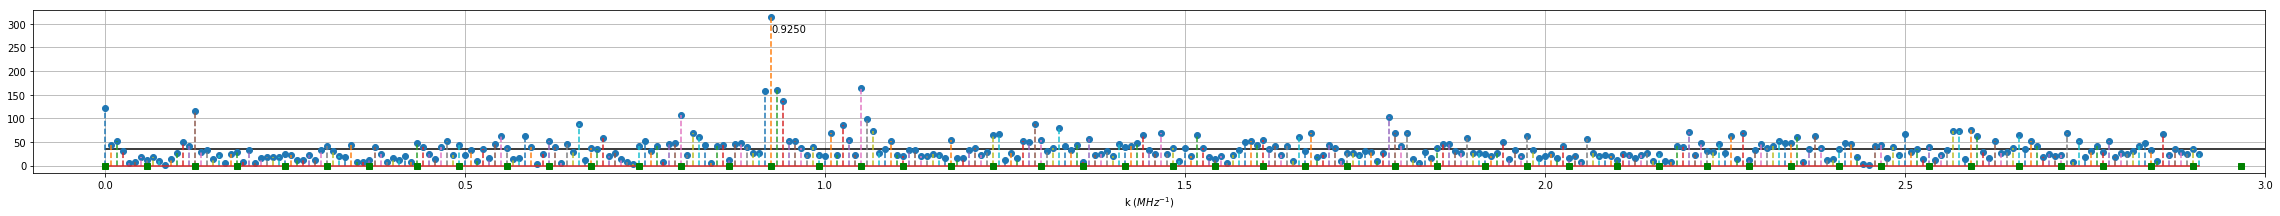

In [17]:
nplot0 = 0
nplot1 = 350
tspec = amp_data[100,:]
fig,ax = plt.subplots(figsize=(40,3))
ax.stem(x[nplot0:nplot1],tspec[nplot0:nplot1],linefmt='--')
ax.text(x[loc1],tspec[loc1]*.9,f'{x[loc1]:.4f}')
ax.plot(x[loc16],np.zeros_like(loc16),'gs')
ax.hlines(amp_thr,0,3)
ax.grid()
ax.set_xlabel('k ($MHz^{-1}$)')
plt.xlim(-0.1,3)

(0, 2.5)

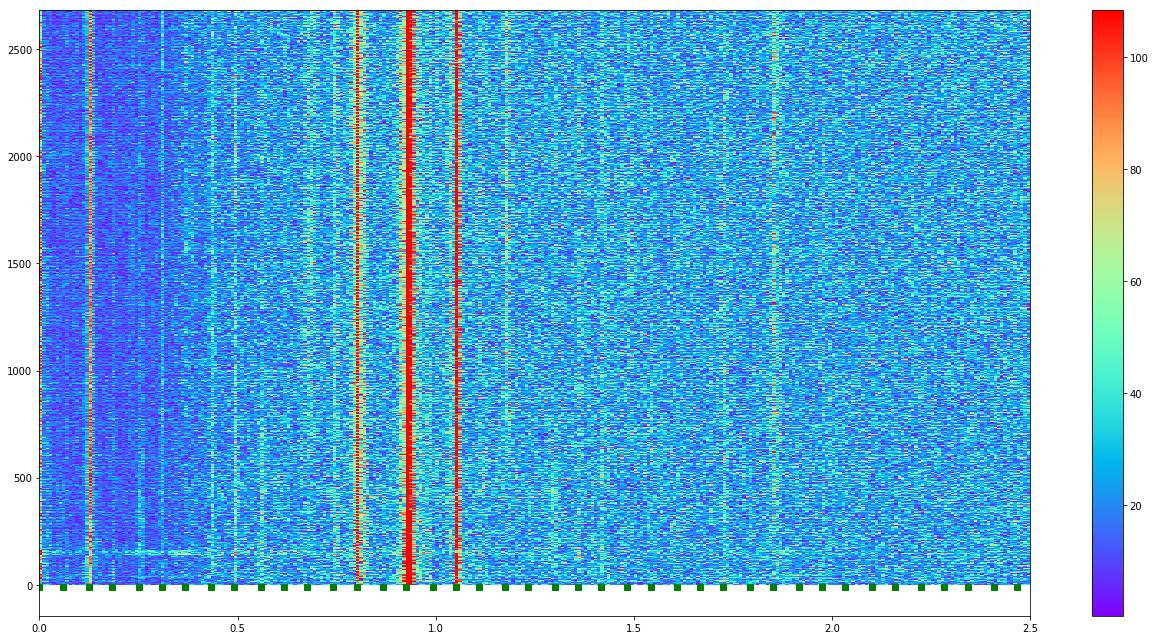

In [18]:
plt.figure(figsize=(18,9))
vmin,vmax = percent_vminmax(amp_data,percent = .999)
plt.imshow(amp_data,origin='lower',aspect='auto',extent=(x[0],x[-1],0,amp_data.shape[0]),
        vmin=vmin,vmax=vmax,cmap='rainbow')
plt.plot(x[loc16],-10 * np.ones_like(x_loc16),'gs')

plt.tight_layout()
plt.colorbar()
plt.xlim(0,2.5)

(0, 3)

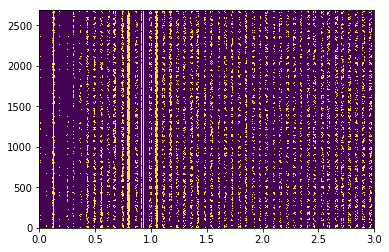

In [18]:
use16 = np.full(len(x),False)
use16[loc16_] = True;use16[loc1] = False ; use16[0] = False
use16 = use16 &  (amp_data >= amp_thr) 

use = (np.abs(np.arange(len(x))-loc1) < sw_n) & (amp_data >= amp_thr) 
plt.imshow(use16,origin = 'lower',aspect = 'auto',extent=(x[0],x[-1],0,amp_data.shape[0]),)
plt.xlim(0,3)

In [19]:
from scipy.interpolate import interp1d
from tqdm import tqdm
x_ = deepcopy(x)

amp_data_inpd = deepcopy(amp_data)
for ti in tqdm(range(amp_data.shape[0])):
    x_mask = x_[~use16[ti]]
    amp_data_mask = amp_data[ti][~use16[ti]]
    amp_data_interp = interp1d(x_mask,amp_data_mask,kind='linear')#,fill_value="extrapolate")
    amp_data_inpd[ti][use16[ti]] = amp_data_interp(x_[use16[ti]])
amp_data_inpd = amp_data - amp_data_inpd
amp_data_inpd[:,0] = amp_data[:,0]
amp_data_inpd[use] = amp_data[use]
amp_data_inpd[amp_data_inpd < 0] = 0

100%|██████████| 2683/2683 [00:01<00:00, 1834.26it/s]


(-0.1, 3)

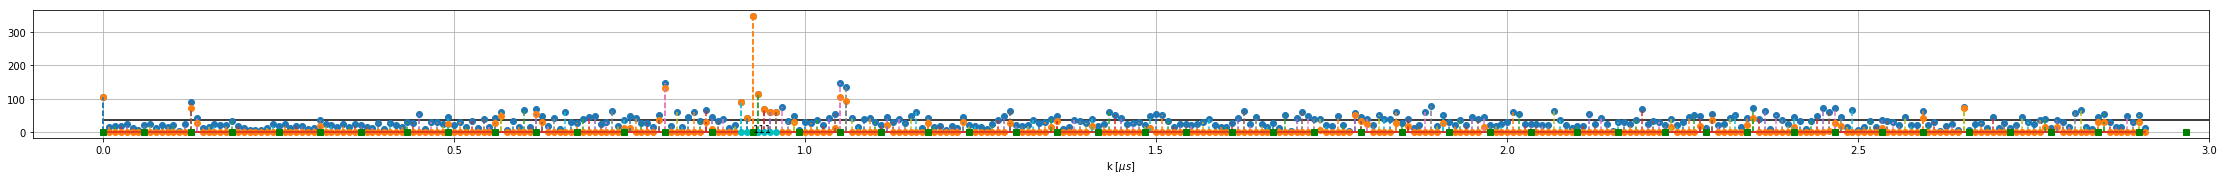

In [21]:
fig = plt.figure(figsize=(39,8))
ax = fig.add_subplot(311) 
ax.stem(x[nplot0:nplot1],amp_data[tn,nplot0:nplot1],linefmt='--',markerfmt ='C0o')
ax.stem(x[nplot0:nplot1],amp_data_inpd[tn,nplot0:nplot1],linefmt='--',markerfmt ='C1o')
ax.text(x[loc1],.1,f'{loc1}')
ax.plot(x[use[tn]],np.zeros_like(x[use[tn]]),'co')
plt.plot(x[loc16],np.zeros_like(loc16),'gs')
ax.hlines(amp_thr,0,3)
ax.grid()
ax.set_xlabel('k [$\mu s$]')
ax.set_xlim(-.1,3)

In [20]:
A_data_inpd =  amp_data_inpd * np.exp(1j*fftf.phi)
A_data_ifft = np.real(np.fft.irfft(A_data_inpd,n=data_rmrfi_low_mw.shape[1]))

if len(is_rfi_num)>0:
    ori_shape = data.shape
    A_data_ifft_ = np.full(ori_shape,np.nan)
    A_data_ifft_[not_rfi_num,:] = A_data_ifft
    A_data_ifft = deepcopy(A_data_ifft_)

In [21]:
sw_fit = A_data_ifft

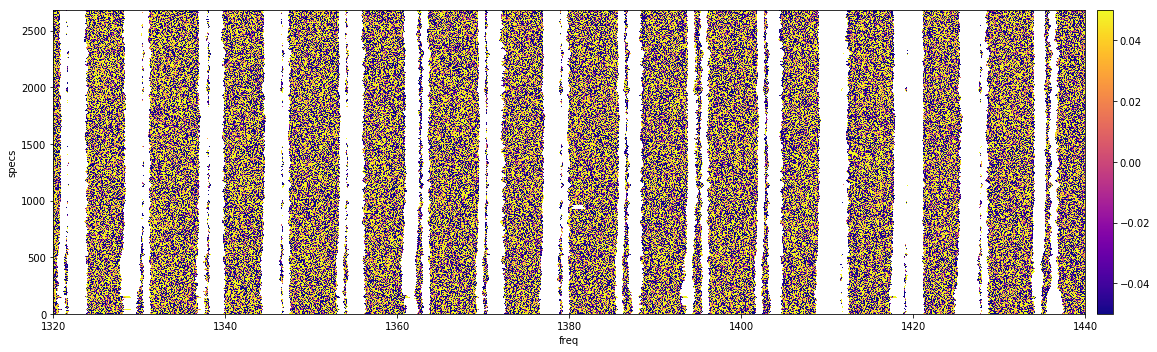

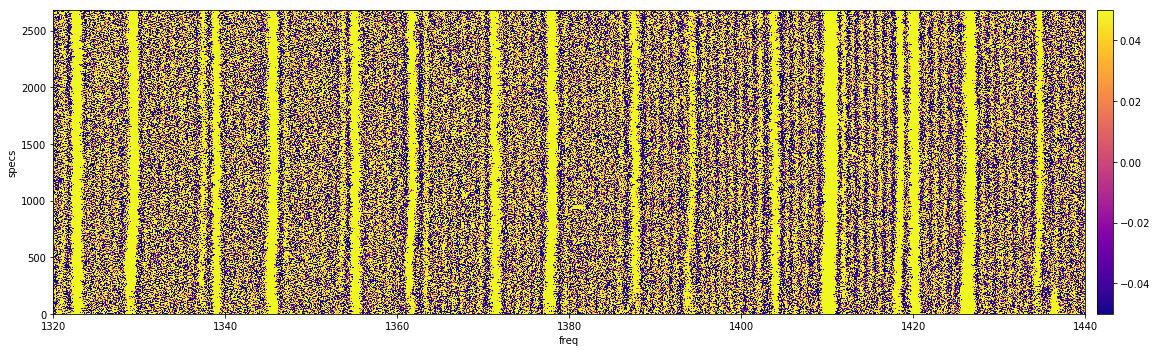

In [22]:
rmsw_data = data - sw_fit
rmsw_data[is_rfi] = np.nan

plot_waterfall(sub,data = rmsw_data,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))  
plot_waterfall(sub,data = data,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))

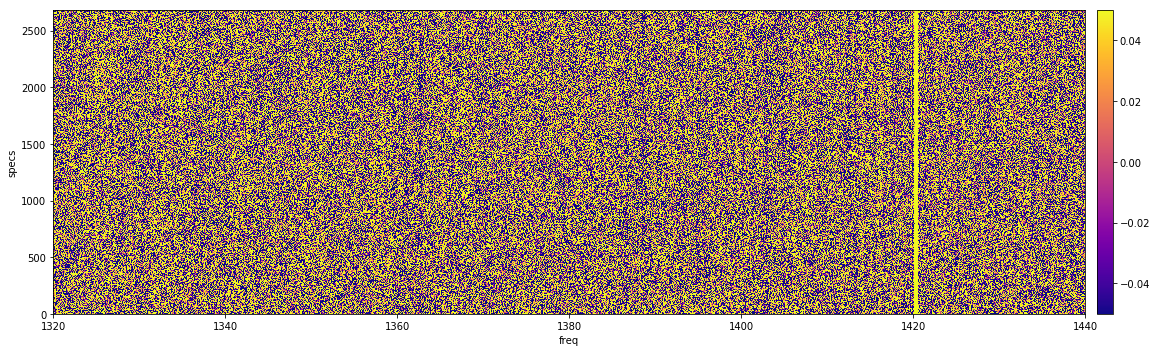

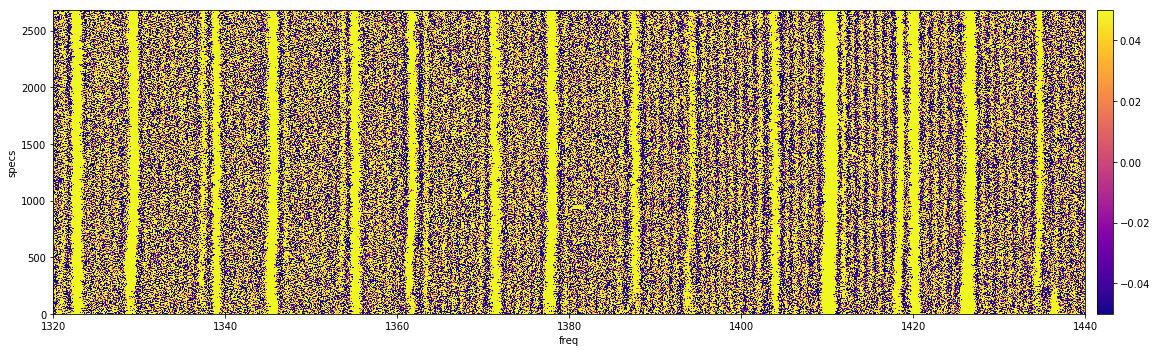

In [23]:
rmsw_data2 = data - sw_fit
rmsw_data2[is_rfi] = data_rmrfi[is_rfi]

plot_waterfall(sub,data = rmsw_data2,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))  
plot_waterfall(sub,data = data,vmin_max=[-.05,.05],cmap='plasma',figsize=(18,5))

(-1.5, 0.5)

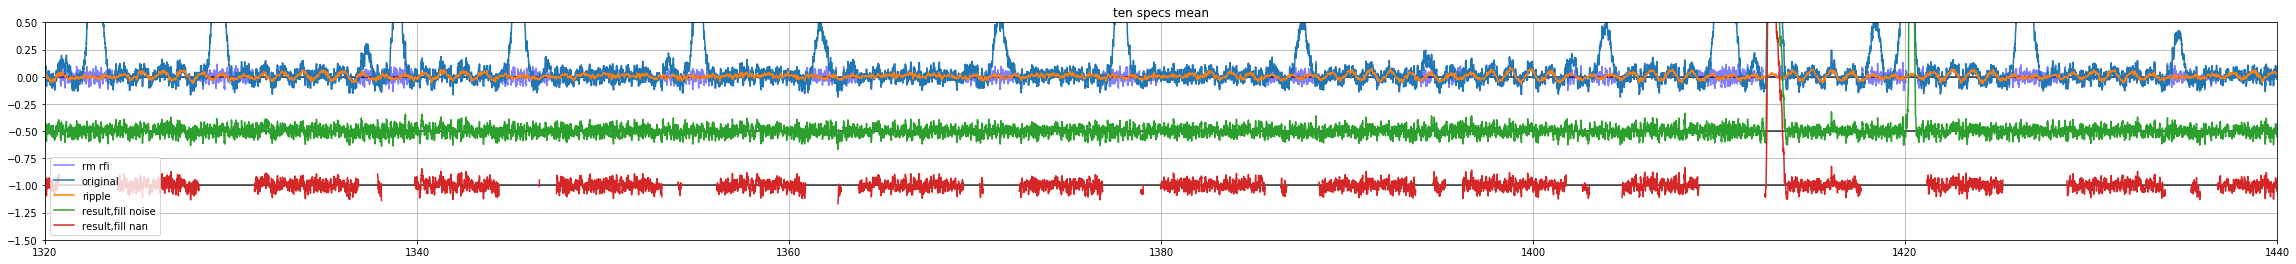

In [24]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-.5,-1],1320,1440,alpha = .8)
ax.plot(freq,np.mean(data_rmrfi_low_mw[tn-5:tn+5,:],axis = 0),'b',label='rm rfi',alpha = .5)
ax.plot(freq,np.mean(data[tn-5:tn+5,:],axis = 0),label='original')
ax.plot(freq,np.mean(sw_fit[tn-5:tn+5,:],axis = 0),label='ripple')
ax.plot(freq,np.mean(rmsw_data2[tn-5:tn+5,:],axis = 0) - .5,label='result,fill noise')
ax.plot(freq,np.mean(rmsw_data[tn-5:tn+5,:],axis = 0) - 1,label='result,fill nan')
ax.grid();ax.legend();ax.set_title('ten specs mean')
ax.set_xlim(1320,1440)
ax.set_ylim(-1.5,.5)

(-3, 1)

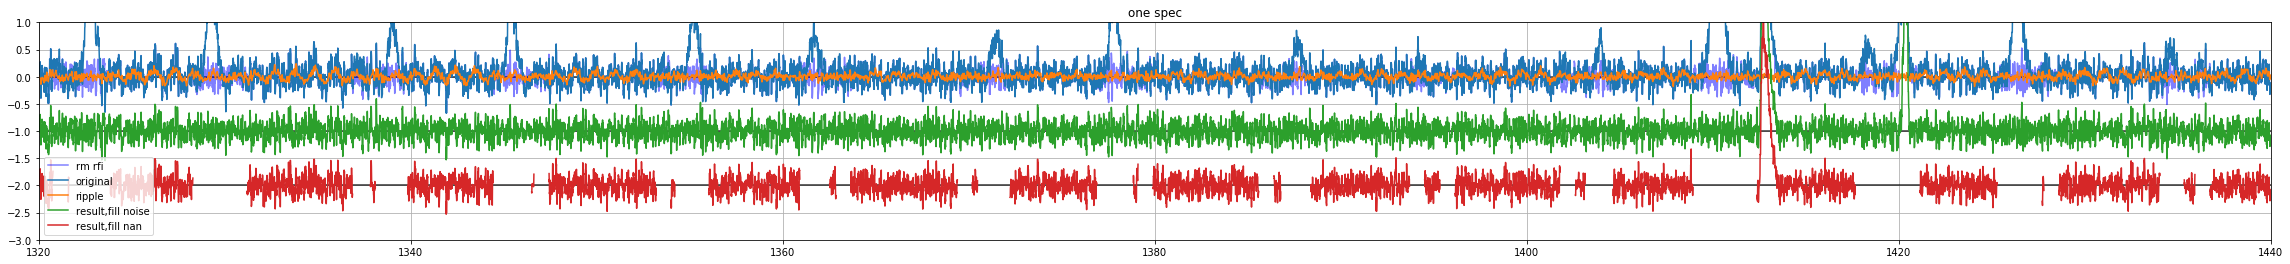

In [25]:
fig = plt.figure(figsize=(40,4))
ax = fig.add_subplot(111)
ax.hlines([0,-1,-2],1320,1440,alpha = .8)
ax.plot(freq, data_rmrfi_low_mw[tn,:],'b',label='rm rfi',alpha = .5)
ax.plot(freq, data[tn,:],label='original')
ax.plot(freq, sw_fit[tn,:],label='ripple')
ax.plot(freq, rmsw_data2[tn,:] - 1,label='result,fill noise')
ax.plot(freq, rmsw_data[tn,:] - 2,label='result,fill nan')
ax.grid();ax.legend();ax.set_title('one spec')
ax.set_xlim(1320,1440)
ax.set_ylim(-3,1)